In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

10. In this problem, you will generate simulated data, and then perform PCA and K-means clustering on the data.

(a) Generate a simulated data set with 20 observations in each of three classes (i.e. 60 observations total), and 50 variables.

Hint: There are a number of functions in Python that you can use to generate data. One example is the normal() method of the random() function in numpy; the uniform() method is another option. Be sure to add a mean shift to the observations in each class so that there are three distinct classes.

In [ ]:
n_class = 3
n_obs = 20
n_var = 50

#用不同的 loc 讓三個類別的中心不同，產生 3 distinct classes
np.random.seed(123)
class1 = np.random.normal(loc=0, scale=1, size=(n_obs, n_var)) #mean=0, std=1
class2 = np.random.normal(loc=3, scale=1, size=(n_obs, n_var))
class3 = np.random.normal(loc=-3, scale=1, size=(n_obs, n_var))

X = np.vstack((class1, class2, class3))
y = np.array([0]*n_obs + [1]*n_obs + [2]*n_obs) #建立標籤 [0,...,0,1,...,1,2...2]

data = pd.DataFrame(X, columns=[f"Var{i+1}" for i in range(n_var)])
data["Class"] = y

data

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var42,Var43,Var44,Var45,Var46,Var47,Var48,Var49,Var50,Class
0,-1.085631,0.997345,0.282978,-1.506295,-0.578600,1.651437,-2.426679,-0.428913,1.265936,-0.866740,...,-1.727669,-0.390900,0.573806,0.338589,-0.011830,2.392365,0.412912,0.978736,2.238143,0
1,-1.294085,-1.038788,1.743712,-0.798063,0.029683,1.069316,0.890706,1.754886,1.495644,1.069393,...,-1.267352,0.181035,1.177862,-0.335011,1.031114,-1.084568,-1.363472,0.379401,-0.379176,0
2,0.642055,-1.977888,0.712265,2.598304,-0.024626,0.034142,0.179549,-1.861976,0.426147,-1.605410,...,0.130215,1.267299,0.332765,0.556549,-0.212080,0.456271,1.544544,-0.239669,0.143308,0
3,0.253816,0.283725,-1.411889,-1.876869,-1.019655,0.167942,0.553856,-0.530675,1.377257,-0.143176,...,-0.029968,0.199582,-0.126118,0.197019,-3.231055,-0.269293,-0.110851,-0.341262,-0.217946,0
4,0.703310,-0.598105,2.200702,0.688297,-0.006307,-0.206662,-0.086522,-0.915307,-0.095203,0.278684,...,0.279663,0.249970,-0.974308,0.435876,-0.318957,0.630488,-2.152493,-1.465116,0.363446,0
5,1.862928,0.835059,-0.682451,-1.692052,0.742686,-0.080583,0.590704,0.115299,0.029643,2.958625,...,0.668317,0.955832,-0.877614,-1.923716,0.695787,1.875801,0.415695,0.160544,0.819761,0
6,0.765055,-0.828989,-0.659151,0.611124,-0.144013,1.316606,-0.704342,0.750610,0.342638,-0.126438,...,-0.447771,0.937850,-0.356663,-1.895176,0.087730,-0.033689,0.179752,-1.040163,1.719035,0
7,-0.323860,-0.188297,-0.900009,-0.931002,-1.222737,-0.393311,-0.957582,2.056467,-1.888492,-1.128331,...,1.161068,-0.098685,-0.214983,-1.773771,-0.407513,-0.291507,0.245379,-0.168426,0.244027,0
8,1.534090,-0.529914,-0.490972,-1.309165,-0.008660,0.976813,-1.751070,-0.665857,0.035941,0.850103,...,-0.550893,-0.398624,0.110453,1.113402,0.142990,-1.256834,0.261989,1.629534,0.065806,0
9,0.129386,-1.262544,-1.402989,-0.637692,-0.326518,0.104061,0.165957,1.601908,0.058687,1.064423,...,-0.232357,-0.824992,-0.256845,-1.050219,0.567880,0.512983,-0.026923,0.311582,-0.142051,0


(b) Perform PCA on the 60 observations and plot the first two principal component score vectors. Use a different color to indicate the observations in each of the three classes. If the three classes appear separated in this plot, then continue on to part (c). If not, then return to part (a) and modify the simulation so that there is greater separation between the three classes. Do not
continue to part (c) until the three classes show at least some separation in the first two principal component score vectors.

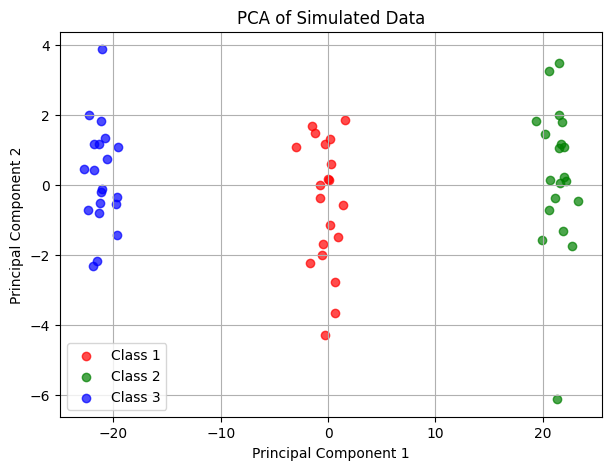

In [ ]:
X_features = X #只取特徵,不要類別標籤

pca = PCA(n_components=2)  #取pca前2個主成分
X_pca = pca.fit_transform(X_features)

plt.figure(figsize=(7,5))
colors = ['red', 'green', 'blue']
labels = ['Class 1', 'Class 2', 'Class 3']
for i in range(3):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1],color=colors[i], label=labels[i], alpha=0.7) #x,y為類別i資料在first/second principle的值

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Simulated Data')
plt.legend()
plt.grid(True)
plt.show()

(c) Perform K-means clustering of the observations with K = 3.

How well do the clusters that you obtained in K-means clustering compare to the true class labels?

Hint: You can use the pd.crosstab() function in Python to compare the true class labels to the class labels obtained by clustering. Be careful how you interpret the results: K-means clustering will arbitrarily number the clusters, so you cannot simply check whether the true class labels and clustering labels are the same.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=123)
kmeans.fit(X)  # 用原始 50 維資料分群
clusters = kmeans.labels_  # 每筆資料的分群結果

comparison = pd.crosstab(y, clusters,
                         rownames=['True Class'],
                         colnames=['K-means Cluster'])

print(comparison)

K-means Cluster   0   1   2
True Class                 
0                 0   0  20
1                 0  20   0
2                20   0   0


(d) Perform K-means clustering with K = 2. Describe your results.

->When K = 2, K-means can only form two clusters, so it tends to merge two of the true classes into one cluster.
This happens because the data actually contain three distinct groups, and forcing K = 2 reduces the separation accuracy.

In [ ]:
kmeans2 = KMeans(n_clusters=2, random_state=123)
kmeans2.fit(X)
clusters2 = kmeans2.labels_

comparison2 = pd.crosstab(y, clusters2,
                          rownames=['True Class'],
                          colnames=['K-means Cluster (K=2)'])
comparison2

K-means Cluster (K=2),0,1
True Class,,
0,20,0
1,0,20
2,20,0


(e) Now perform K-means clustering with K = 4, and describe your results.

-> When K = 4, K-means attempts to create four clusters even though the data only contain three natural groups. As a result, one of the true clusters is split into two smaller clusters.

In [ ]:
kmeans4 = KMeans(n_clusters=4, random_state=123)
kmeans4.fit(X)
clusters4 = kmeans4.labels_

comparison4 = pd.crosstab(y, clusters4,
                          rownames=['True Class'],
                          colnames=['K-means Cluster (K=4)'])
comparison4

K-means Cluster (K=4),0,1,2,3
True Class,,,,
0,0,0,20,0
1,0,20,0,0
2,4,0,0,16


(f) Now perform K-means clustering with K = 3 on the first two
principal component score vectors, rather than on the raw data.
That is, perform K-means clustering on the 60 × 2 matrix of
which the first column is the first principal component score
vector, and the second column is the second principal component
score vector. Comment on the results.

-> The data points for each class form distinct clusters in the PCA plot, and K-means correctly identifies these clusters, demonstrating high clustering accuracy.

K-means Cluster (PCA)   0   1   2
True Class                       
0                       0   0  20
1                       0  20   0
2                      20   0   0


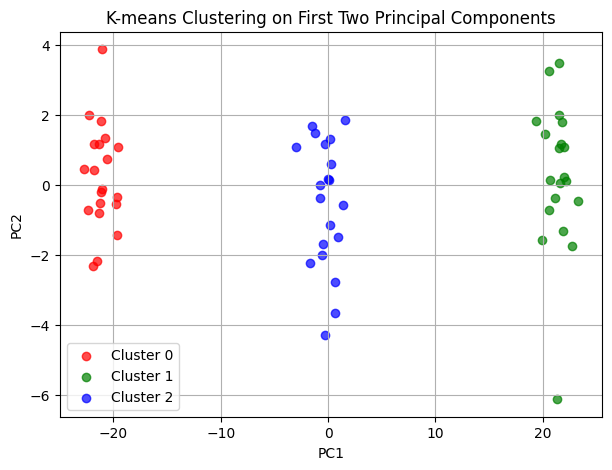

In [ ]:
kmeans_pca = KMeans(n_clusters=3, random_state=123)
kmeans_pca.fit(X_pca)  # X_pca is 60x2
clusters_pca = kmeans_pca.labels_

comparison_pca = pd.crosstab(y, clusters_pca,
                             rownames=['True Class'],
                             colnames=['K-means Cluster (PCA)'])
print(comparison_pca)

# plot PCA points with K-means clusters
plt.figure(figsize=(7,5))
colors = ['red', 'green', 'blue']

for i in range(3):
    plt.scatter(X_pca[clusters_pca == i, 0], X_pca[clusters_pca == i, 1],
                color=colors[i], alpha=0.7, label=f'Cluster {i}')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clustering on First Two Principal Components')
plt.legend()
plt.grid(True)
plt.show()


(g) Using the StandardScaler() estimator, perform K-means clustering with K = 3 on the data after scaling each variable to have standard deviation one. How do these results compare to those obtained in (b)? Explain.

-> Performing K-means on standardized data ensures that all variables contribute equally to the clustering process. In this dataset, since the variables were generated with similar scales, the clustering results after scaling are similar to those obtained without scaling.

In [ ]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, random_state=123)
kmeans_scaled.fit(X_scaled)
clusters_scaled = kmeans_scaled.labels_

comparison_scaled = pd.crosstab(y, clusters_scaled,
                                rownames=['True Class'],
                                colnames=['K-means Cluster (Scaled)'])
print(comparison_scaled)


K-means Cluster (Scaled)   0   1   2
True Class                          
0                          0   0  20
1                          0  20   0
2                         20   0   0
